In [1]:
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils import data
import time
import json
import pandas as pd

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
path = Path('../data/processed/item_features')
title_path = path / 'title_svd512.npy'
year_path = path / 'year_minmax.npy'
genres_path = path / 'genres.npy'

In [5]:
title = np.load(title_path)
year = np.load(year_path)
genres = np.load(genres_path)

In [6]:
X = np.concatenate([title, year, genres], axis=-1)

In [7]:
X

array([[ 6.8431546e-04,  3.9901346e-02,  2.3633353e-02, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [-1.9209601e-09,  7.7628108e-09, -1.2134791e-08, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 1.2695480e-02,  9.5645798e-04,  4.4097258e-03, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       ...,
       [ 1.0805172e-09,  5.7395995e-09, -2.7672703e-08, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 2.5726717e-02,  3.0221413e-03,  2.9754069e-02, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 6.2697270e-10, -1.5037549e-09,  1.6673376e-08, ...,
         1.0000000e+00,  0.0000000e+00,  0.0000000e+00]], dtype=float32)

In [8]:
X.shape

(3706, 531)

In [9]:
X = torch.tensor(X, dtype=torch.float32)

In [10]:
sid_pairs_path = '../data/processed/sid_pairs/co_pairs_neighbors.parquet'
df_sid = pd.read_parquet(sid_pairs_path)
df_sid.head()

,item_idx,item_next
0,2969,1178
1,1178,1574
2,1574,957
3,957,2147
4,2147,1658


In [11]:
sid_pairs_idxs = torch.tensor(df_sid.values, dtype=torch.int)

In [12]:
sid_pairs_idxs

tensor([[2969, 1178],
        [1178, 1574],
        [1574,  957],
        ...,
        [ 225, 2709],
        [2709, 1741],
        [1741, 1618]], dtype=torch.int32)

In [13]:
class SID_Pairs(data.Dataset):
    def __init__(self, x, pairs):
        super().__init__()
        self.pairs = pairs
        self.data = x
    def __getitem__(self, idx):
        pair = self.pairs[idx]
        item, item_pos = self.data[pair[0]], self.data[pair[1]]
        return item, item_pos
    def __len__(self):
        return self.pairs.shape[0]
        
class Data(data.Dataset):
    def __init__(self, x):
        super().__init__()
        self.data = x

    def __getitem__(self, idx):
        return self.data[idx], self.data[idx]

    def __len__(self):
        return self.data.shape[0]

ds = Data(X)
sp = SID_Pairs(X, sid_pairs_idxs)

n_train = 0.95
n_val = 0.05
batch_size = 512

train_ds, val_ds = data.random_split(ds, [n_train, n_val],  generator=torch.Generator().manual_seed(42))
train_data = data.DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_data = data.DataLoader(val_ds, batch_size=len(val_ds), shuffle=False, drop_last=False)

sid_pairs = data.DataLoader(sp, batch_size=batch_size, shuffle=True, drop_last=True)

In [14]:
class Encoder(nn.Module):
    def __init__(self, in_d: int, h_d: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_d, 256),
            nn.ReLU(),
            nn.Linear(256, h_d)
        )
    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, out_d: int, h_d: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(h_d, 256),
            nn.ReLU(),
            nn.Linear(256, out_d)
        )

    def forward(self, h):
        return self.net(h)

class MultiResolutionCodebooks(nn.Module):
    def __init__(self, h_d: int, n_levels: int):
        super().__init__()
        self.h_d = h_d
        self.Naive_Masking = False
        self.Progressive_Masking = False
        self.epoch_devider = 100
        self.current_epoch = 0
        self.n_levels = n_levels
        self.codebooks = nn.ModuleList([
            nn.Embedding(2048 // (2 ** level), self.h_d) for level in range(self.n_levels)
        ])

    def set_naive_masking(self, on: bool):
        self.Naive_Masking = on

    def set_progressive_masking(self, on: bool, current_epoch, epoch_devider: int):
        self.current_epoch = current_epoch
        self.epoch_devider = epoch_devider
        self.Progressive_Masking = True
        
    def forward(self, h):
        SIDs = [0] * self.n_levels
        r_list = [0] * self.n_levels
        q_list = [0] * self.n_levels
        z_q_sum_arr = [0] * self.n_levels
      
        for i in range(self.n_levels):
            r_in = h
            current_codebook = self.codebooks[i].weight
            idxs = torch.argmin(torch.sum(((current_codebook[None, :, :] - r_in[:, None, :]) ** 2), dim=2), dim=1)
            q = current_codebook[idxs]
            
            h = r_in - q
            z_q_sum_arr[i] = q

            SIDs[i] = idxs
            r_list[i] = r_in
            q_list[i] = q

        z_q_sum_arr = torch.stack(z_q_sum_arr, dim=1)
        if self.Naive_Masking:
            r = torch.randint(1, self.n_levels + 1, (1,)).item()
            z_q = z_q_sum_arr[:, :r, :].sum(dim=1)
            
        elif self.Progressive_Masking:
            r_max = min(self.n_levels, self.current_epoch // self.epoch_devider + 1)
            r = torch.randint(1, r_max + 1, (1,)).item()
            z_q = z_q_sum_arr[:, :r, :].sum(dim=1)
            
        else:
            z_q = z_q_sum_arr.sum(dim=1)
            
        SIDs = torch.stack(SIDs, dim=1)
        r_list = torch.stack(r_list, dim=1)
        q_list = torch.stack(q_list, dim=1)

        return z_q, SIDs, r_list, q_list    

class RQVAE(nn.Module):
    def __init__(self, in_d: int, h_d: int, n_levels: int, ):
        super().__init__()
        self.encoder = Encoder(in_d, h_d)
        self.codebooks = MultiResolutionCodebooks(h_d, n_levels)
        self.decoder = Decoder(in_d, h_d)    

    def forward(self, x):
        h = self.encoder(x)
        z_q, SIDs, r_list, q_list = self.codebooks(h)

        # STE: forward - z_q, backward - h
        z_q_st = h + (z_q - h).detach()

        x_hat = self.decoder(z_q_st)
        
        return x_hat, h, z_q, SIDs, r_list, q_list 

    def set_naive_masking(self, on: bool):
        self.codebooks.set_naive_masking(on)

    def set_progressive_masking(self, on: bool, current_epoch, epoch_devider: int):
        self.codebooks.set_progressive_masking(on, current_epoch, epoch_devider)

In [15]:
class RQVAELoss(nn.Module):
    def __init__(self, beta: float = 0.5):
        super().__init__()
        self.beta = beta
        
    def co_occurence_contrastive_regularization(self, p, p_pos):
        B = p.size(0)
        z = torch.cat([p, p_pos], dim=0)          # (2B, d)
    
        logits = (z @ z.t())            # dot-product / temperature
        logits.fill_diagonal_(-1e9)
    
        # stable exp, nan without stab
        logits = logits - logits.max(dim=1, keepdim=True).values
    
        pos = (torch.arange(2 * B, device=z.device) + B) % (2 * B)
        num = torch.exp(logits[torch.arange(2*B, device=z.device), pos])  # (2B,)
        denom = torch.exp(logits).sum(dim=1)                               # (2B,)
        loss = -(num / denom).mean()
        return loss

        
    def forward(self, x, x_hat, r_list, q_list,  p=None, p_pos=None):
        L = r_list.shape[1]
        recon_loss = F.mse_loss(x, x_hat)
        codebook_loss = F.mse_loss(r_list.detach(), q_list) * L
        commit_loss = self.beta * F.mse_loss(r_list, q_list.detach()) * L
        rq_loss = codebook_loss + commit_loss
        total = recon_loss + rq_loss

        if (p is not None) and (p_pos is not None):
            con_loss = self.co_occurence_contrastive_regularization(p, p_pos)
        else:
            con_loss = torch.tensor(0.0)

        total += con_loss
            
        return total, recon_loss, codebook_loss, commit_loss, con_loss

In [16]:
in_d = X.shape[-1]
h_d = 64
n_levels = 5
codebook_sizes = [1024 // (2 ** level) for level in range(n_levels)]  

In [17]:
def sid_metrics(SIDs, codebook_sizes):
    """
    SIDs: (batch_size, n_levels)
    codebook_sizes: (n_levels // 2 ^ (level - 1))
    """
    with torch.no_grad():
        n_levels = SIDs.shape[1]
        U = [len(SIDs[:, l].unique()) for l in range(n_levels)]

        PPL = [0.0] * n_levels

        for level in range(n_levels):
            ids = SIDs[:, level].long()
            counts = torch.bincount(ids, minlength=codebook_sizes[level])
            p = counts / counts.sum()
            p_notzero = p[p > 0]
            H = -(p_notzero * torch.log(p_notzero)).sum()
            ppl = torch.exp(H)
            PPL[level] = ppl.item()

    return U, PPL

In [18]:
def sid_uniqueness_percent(model, X, device):
    """% уникальных SID-векторов на всей выборке X."""
    model.eval()
    with torch.no_grad():
        _, _, _, SIDs, _, _ = model(X.to(device))      # (N, n_levels)
    s = SIDs.detach().cpu().numpy()
    return 100.0 * len(np.unique(s, axis=0)) / s.shape[0]

In [19]:
history = {
    'train_loss': [],
    'val_loss': [],
    'train_recon': [],
    'val_recon': [],
    'train_cb': [],
    'val_cb': [],
    'train_com': [],
    'val_com': [],
    'train_U': [],
    'val_U': [],
    'train_PPL': [],
    'val_PPL': [],
    'train_con': []
}

model = RQVAE(in_d, h_d, n_levels)
model.to(device)
optimizer = optim.Adam(params=model.parameters(), lr=0.005)
epochs = 10000
beta = 0.0003
epoch_devider = 750
lambda_con = 0.5
loss_func = RQVAELoss(beta)

path = Path("../runs")
run_id = time.strftime("%Y-%m-%d_%H-%M-%S")
run_dir = path / f"5codebooks_10k_epochs"
run_dir.mkdir(parents=True, exist_ok=True) 

config = {
    "variant": "baseline_rqvae_title_year_genres",
    "in_d": in_d,
    "h_d": h_d,
    "n_levels": n_levels,
    "codebook_sizes": codebook_sizes,
    "lr": optimizer.param_groups[0]["lr"],
    "beta": beta,
    "epochs": epochs,
    "batch_size": batch_size,
    "device": str(device),
}

json.dump(config, open(run_dir/"config.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)

best_val = float("inf")

# co-occurence contrastive regularization
sid_iter = iter(sid_pairs)   

# ---------- INSIDE YOUR TRAINING SCRIPT (REPLACE YOUR LOOP PART WITH THIS VERSION) ----------
best_u = -1.0
best_u_epoch = -1

sid_iter = iter(sid_pairs)

for _e in range(epochs):

    model.train()
    model.set_progressive_masking(True, _e, epoch_devider)

    U_sum = np.zeros(n_levels, dtype=np.float64)
    PPL_sum = np.zeros(n_levels, dtype=np.float64)
    loss_sum = 0.0
    recon_sum = 0.0
    cb_sum = 0.0
    com_sum = 0.0
    con_sum = 0.0
    n_batches = 0

    train_tqdm = tqdm(train_data, leave=True, desc=f"train {_e+1} / {epochs}")

    for x_train, _ in train_tqdm:
        x_train = x_train.to(device)

        # ----- contrastive pairs -----
        try:
            x_pair, x_pair_pos = next(sid_iter)
        except StopIteration:
            sid_iter = iter(sid_pairs)
            x_pair, x_pair_pos = next(sid_iter)

        x_pair = x_pair.to(device)
        x_pair_pos = x_pair_pos.to(device)

        p = model.encoder(x_pair)
        p_pos = model.encoder(x_pair_pos)

        predict, h, z_q, SIDs, r_list, q_list = model(x_train)
        total, recon, cb, com, con = loss_func(x_train, predict, r_list, q_list, p, p_pos)
        total = total + lambda_con * con

        optimizer.zero_grad()
        total.backward()
        optimizer.step()

        # metrics (batch)
        U_batch, PPL_batch = sid_metrics(SIDs, codebook_sizes)
        U_sum += np.array(U_batch, dtype=np.float64)
        PPL_sum += np.array(PPL_batch, dtype=np.float64)

        loss_sum += float(total.item())
        recon_sum += float(recon.item())
        cb_sum += float(cb.item())
        com_sum += float(com.item())
        con_sum += float(con.item())
        n_batches += 1

        # show current batch losses
        train_tqdm.set_postfix(
            total=f"{total.item():.4f}",
            recon=f"{recon.item():.4f}",
            cb=f"{cb.item():.4f}",
            com=f"{com.item():.4f}",
            con=f"{con.item():.4f}",
        )

    # ----- epoch averages -----
    train_loss_for_epoch = loss_sum / max(1, n_batches)
    U_for_epoch = U_sum / max(1, n_batches)
    PPL_for_epoch = PPL_sum / max(1, n_batches)
    recon_for_epoch = recon_sum / max(1, n_batches)
    cb_for_epoch = cb_sum / max(1, n_batches)
    com_for_epoch = com_sum / max(1, n_batches)
    con_for_epoch = con_sum / max(1, n_batches)

    history["train_loss"].append(train_loss_for_epoch)
    history["train_U"].append(U_for_epoch)
    history["train_PPL"].append(PPL_for_epoch)
    history["train_recon"].append(recon_for_epoch)
    history["train_cb"].append(cb_for_epoch)
    history["train_com"].append(com_for_epoch)
    history["train_con"].append(con_for_epoch)

    # ----- uniqueness on ALL X -----
    u_all = sid_uniqueness_percent(model, X, device)
    history.setdefault("sid_uniqueness_all", []).append(float(u_all))

    # save best by uniqueness
    if u_all > best_u:
        best_u = float(u_all)
        best_u_epoch = int(_e)
        torch.save(
            {
                "epoch": _e,
                "best_u": best_u,
                "model": model.state_dict(),
                "optim": optimizer.state_dict(),
                "config": config,
            },
            run_dir / "checkpoint_best_u.pt",
        )

    # show end-of-epoch summary in tqdm line
    train_tqdm.set_postfix(
        avg_loss=f"{train_loss_for_epoch:.4f}",
        u=f"{u_all:.2f}%",
        best_u=f"{best_u:.2f}%",
    )
        # ====== END OF TRAIN EPOCH: SID uniqueness + best logging ======
    
    # важно: выключаем progressive masking для честной оценки "использования кодбуков"
    model.set_progressive_masking(False, _e, epoch_devider)
    
    u_all = sid_uniqueness_percent(model, X, device)   # % уникальных SID по всей матрице X
    history.setdefault("sid_uniqueness_all", []).append(float(u_all))
    
    # best by uniqueness
    if u_all > best_u:
        best_u = float(u_all)
        best_u_epoch = int(_e)
    
        torch.save(
            {
                "epoch": _e,
                "best_u": best_u,
                "model": model.state_dict(),
                "optim": optimizer.state_dict(),
                "config": config,
            },
            run_dir / "checkpoint_best_u.pt",
        )
    
    # печать отдельной строкой (это ТОЧНО увидишь в выводе)
    tqdm.write(f"[epoch {_e+1}/{epochs}] SID-uniqueness={u_all:.2f}% | best={best_u:.2f}% (epoch {best_u_epoch+1})")
    

    # --------------------- VAL -------------------------
    model.eval()
    model.set_progressive_masking(False, _e, epoch_devider)

    with torch.no_grad():
        U_sum = np.zeros(n_levels, dtype=np.float64)
        PPL_sum = np.zeros(n_levels, dtype=np.float64)
        loss_sum = 0.0
        recon_sum = 0.0
        cb_sum = 0.0
        com_sum = 0.0
        n_batches = 0

        val_tqdm = tqdm(val_data, leave=False, desc=f"val {_e+1}/{epochs}")

        for x_val, _ in val_tqdm:
            x_val = x_val.to(device)

            predict, h, z_q, SIDs, r_list, q_list = model(x_val)
            total, recon, cb, com, _temp = loss_func(x_val, predict, r_list, q_list)

            val_tqdm.set_postfix(
                total=f"{total.item():.4f}",
                recon=f"{recon.item():.4f}",
                cb=f"{cb.item():.4f}",
                com=f"{com.item():.4f}",
            )

            U_batch, PPL_batch = sid_metrics(SIDs, codebook_sizes)
            U_sum += np.array(U_batch, dtype=np.float64)
            PPL_sum += np.array(PPL_batch, dtype=np.float64)

            loss_sum += float(total.item())
            recon_sum += float(recon.item())
            cb_sum += float(cb.item())
            com_sum += float(com.item())
            n_batches += 1

        val_loss_for_epoch = loss_sum / max(1, n_batches)
        val_recon_for_epoch = recon_sum / max(1, n_batches)
        val_cb_for_epoch = cb_sum / max(1, n_batches)
        val_com_for_epoch = com_sum / max(1, n_batches)
        val_U_for_epoch = U_sum / max(1, n_batches)
        val_PPL_for_epoch = PPL_sum / max(1, n_batches)

    history["val_loss"].append(val_loss_for_epoch)
    history["val_U"].append(val_U_for_epoch)
    history["val_PPL"].append(val_PPL_for_epoch)
    history["val_recon"].append(val_recon_for_epoch)
    history["val_cb"].append(val_cb_for_epoch)
    history["val_com"].append(val_com_for_epoch)

    # ----- checkpoints -----
    torch.save(
        {"epoch": _e, "model": model.state_dict(), "optim": optimizer.state_dict(), "config": config},
        run_dir / "checkpoint_last.pt",
    )

    if val_loss_for_epoch < best_val:
        best_val = float(val_loss_for_epoch)
        torch.save(
            {
                "epoch": _e,
                "best_val": best_val,
                "model": model.state_dict(),
                "optim": optimizer.state_dict(),
                "config": config,
            },
            run_dir / "checkpoint_best.pt",
        )

    # ----- dump metrics -----
    json.dump(
        history,
        open(run_dir / "metrics.json", "w", encoding="utf-8"),
        ensure_ascii=False,
        indent=2,
        default=lambda x: x.tolist(),
    )

# optional: print final best uniqueness
print(f"Best SID uniqueness: {best_u:.2f}% at epoch {best_u_epoch}")


C:\Users\User\.conda\conda.new\envs\plum\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
train 1 / 10000: 100%|██████████| 6/6 [00:00<00:00, 17.20it/s, cb=4.6153, com=0.0014, con=-0.0010, recon=0.0069, total=4.6222]


[epoch 1/10000] SID-uniqueness=0.11% | best=0.11% (epoch 1)


train 2 / 10000: 100%|██████████| 6/6 [00:00<00:00, 35.55it/s, cb=4.1419, com=0.0012, con=-0.0012, recon=0.0046, total=4.1460]


[epoch 2/10000] SID-uniqueness=0.13% | best=0.13% (epoch 2)


train 3 / 10000: 100%|██████████| 6/6 [00:00<00:00, 61.95it/s, cb=3.7358, com=0.0011, con=-0.0010, recon=0.0038, total=3.7392]


...

train 9999 / 10000: 100%|██████████| 6/6 [00:00<00:00, 47.75it/s, cb=11.4991, com=0.0034, con=-0.0010, recon=0.0034, total=11.5045]


[epoch 9999/10000] SID-uniqueness=91.31% | best=94.95% (epoch 7222)


train 10000 / 10000: 100%|██████████| 6/6 [00:00<00:00, 47.92it/s, cb=12.0926, com=0.0036, con=-0.0010, recon=0.0033, total=12.0981]


[epoch 10000/10000] SID-uniqueness=91.34% | best=94.95% (epoch 7222)


Best SID uniqueness: 94.95% at epoch 7221


In [20]:
def plot_history(history):
    # 1) Losses
    plt.figure()
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Total loss")
    plt.show()

    # 2) Recon / codebook / commit
    plt.figure()
    plt.plot(history["train_recon"], label="train_recon")
    plt.plot(history["val_recon"], label="val_recon")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("value")
    plt.title("Reconstruction")
    plt.show()

    plt.figure()
    plt.plot(history["train_cb"], label="train_cb")
    plt.plot(history["val_cb"], label="val_cb")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("value")
    plt.title("Codebook loss")
    plt.show()

    plt.figure()
    plt.plot(history["train_com"], label="train_commit")
    plt.plot(history["val_com"], label="val_commit")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("value")
    plt.title("Commit loss")
    plt.show()

    # 3) Contrastive (если есть)
    if "train_con" in history and len(history["train_con"]) > 0:
        plt.figure()
        plt.plot(history["train_con"], label="train_con")
        plt.legend()
        plt.xlabel("epoch")
        plt.ylabel("value")
        plt.title("Contrastive loss")
        plt.show()

    # 4) U по уровням (train_U/val_U — это массивы по n_levels)
    if "train_U" in history and len(history["train_U"]) > 0:
        train_U = np.array(history["train_U"])  # (epochs, n_levels)
        plt.figure()
        for l in range(train_U.shape[1]):
            plt.plot(train_U[:, l], label=f"U_train_l{l}")
        plt.legend()
        plt.xlabel("epoch")
        plt.ylabel("unique codes")
        plt.title("Code usage (train)")
        plt.show()

    if "val_U" in history and len(history["val_U"]) > 0:
        val_U = np.array(history["val_U"])
        plt.figure()
        for l in range(val_U.shape[1]):
            plt.plot(val_U[:, l], label=f"U_val_l{l}")
        plt.legend()
        plt.xlabel("epoch")
        plt.ylabel("unique codes")
        plt.title("Code usage (val)")
        plt.show()

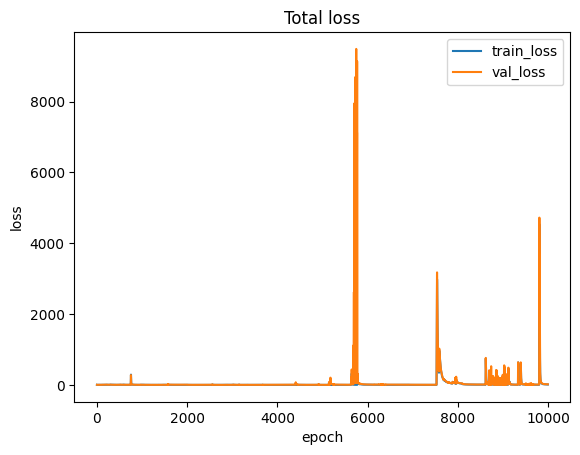

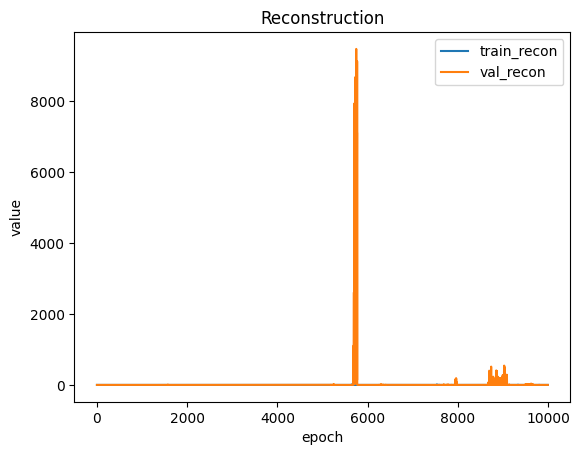

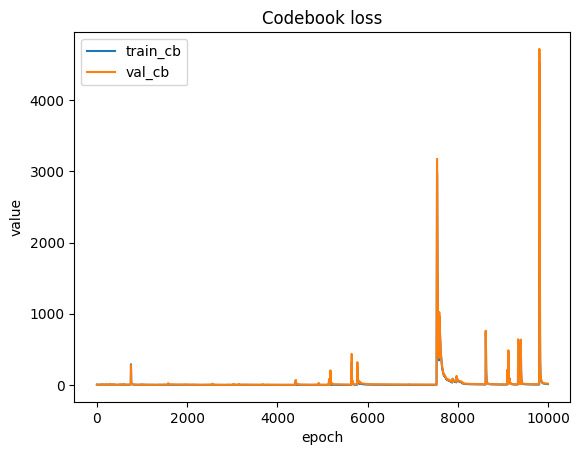

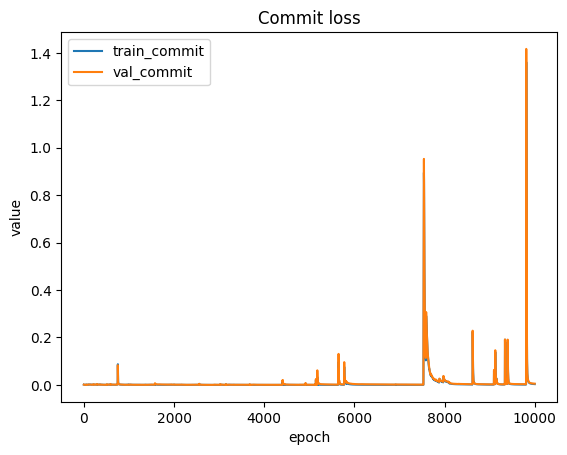

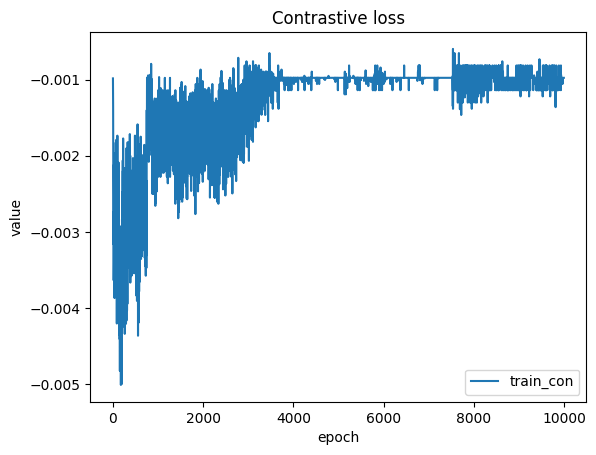

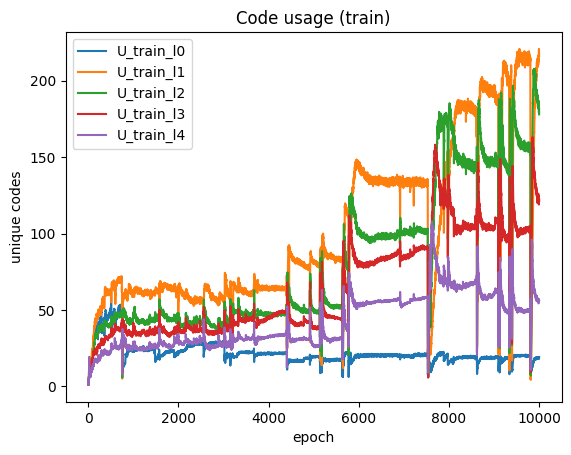

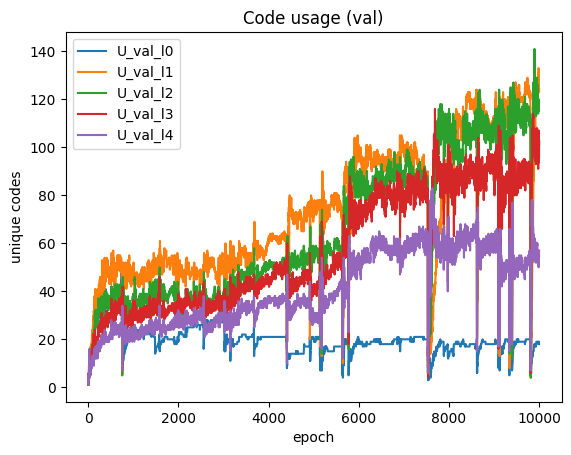

In [21]:
plot_history(history)

In [22]:
model.eval()

with torch.no_grad():
    X = X.to(device)
    _, _, _, SIDs, _, _ = model(X)
    
SIDs  = SIDs.to('cpu').numpy()
unique_sids = len(np.unique(SIDs, axis=0))

print(unique_sids / SIDs.shape[0] * 100)



91.3383702104695


In [23]:
unique_sids

3385